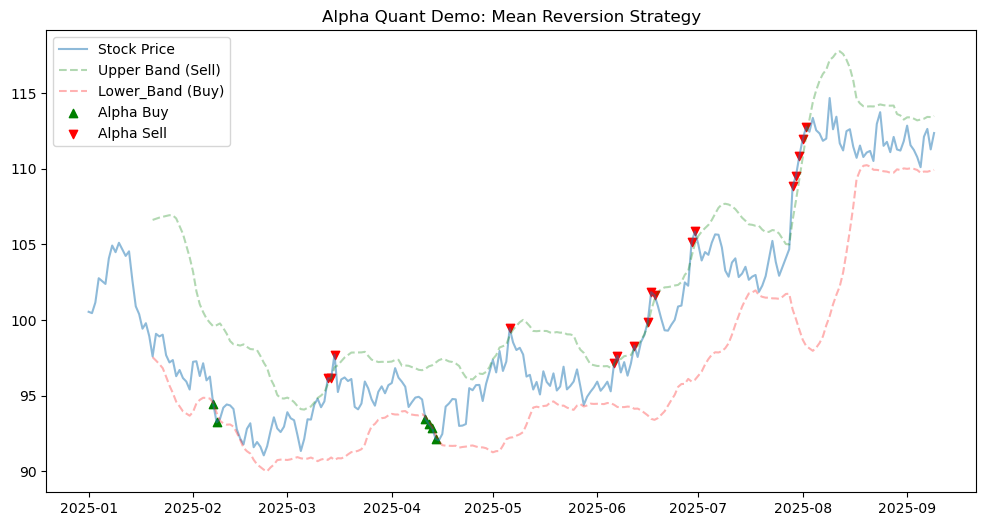

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Synthetic Market Data
np.random.seed(42)
n_days = 252
returns = np.random.normal(0.0005, 0.01, n_days)
price = 100 * np.exp(np.cumsum(returns))
dates = pd.date_range(start='2025-01-01', periods=n_days)
df = pd.DataFrame({'Price': price}, index=dates)

# 2. Alpha Signal Generation (Bollinger Bands)
window = 20
df['Moving_Avg'] = df['Price'].rolling(window=window).mean()
df['Std_Dev'] = df['Price'].rolling(window=window).std()

# Upper and Lower bands (The "Normal" range)
df['Upper_Band'] = df['Moving_Avg'] + (2 * df['Std_Dev'])
df['Lower_Band'] = df['Moving_Avg'] - (2 * df['Std_Dev'])

# 3. The Quantitative Strategy (The Alpha)
# Buy when price is below Lower Band (Oversold)
# Sell when price is above Upper Band (Overbought)
df['Signal'] = 0
df.loc[df['Price'] < df['Lower_Band'], 'Signal'] = 1  # Long Position
df.loc[df['Price'] > df['Upper_Band'], 'Signal'] = -1 # Short Position

# 4. Backtest: Calculate Strategy Returns
df['Market_Return'] = df['Price'].pct_change()
df['Strategy_Return'] = df['Market_Return'] * df['Signal'].shift(1)
df['Cumulative_Alpha'] = (1 + df['Strategy_Return'].fillna(0)).cumprod()

# 5. Visualize the "Edge"
plt.figure(figsize=(12, 6))
plt.plot(df['Price'], label='Stock Price', alpha=0.5)
plt.plot(df['Upper_Band'], 'g--', label='Upper Band (Sell)', alpha=0.3)
plt.plot(df['Lower_Band'], 'r--', label='Lower_Band (Buy)', alpha=0.3)
plt.scatter(df.index[df['Signal'] == 1], df['Price'][df['Signal'] == 1], marker='^', color='green', label='Alpha Buy')
plt.scatter(df.index[df['Signal'] == -1], df['Price'][df['Signal'] == -1], marker='v', color='red', label='Alpha Sell')
plt.title('Alpha Quant Demo: Mean Reversion Strategy')
plt.legend()
plt.show()